# 04 – Treniranje i usporedba modela

U ovom notebooku treniram modele strojnog učenja za predikciju *churn-a* (hoće li korisnik napustiti uslugu).
Koristim očišćeni dataset (`telecom_churn_clean.csv`) iz prethodnog koraka te uspoređujem dva modela:

- Logistic Regression (baseline model)
- Random Forest (nelinearni model)

Za evaluaciju koristim accuracy, precision, recall, F1-score, ROC-AUC i matricu konfuzije.


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns

possible_paths = [
    Path("data/Telco_customer_clean.csv"),
    Path("../data/Telco_customer_clean.csv"),
    Path("/content/drive/MyDrive/csv/Telco_customer_clean.csv")
]

for p in possible_paths:
    if p.exists():
        DATA_PATH = p
        break

df = pd.read_csv(DATA_PATH)
print("Using data file:", DATA_PATH.resolve())
df.shape


Using data file: /content/drive/MyDrive/csv/Telco_customer_clean.csv


(7043, 23)

## Uklanjanje "data leakage" stupaca

Neki stupci sadrže informacije koje su poznate tek nakon što se churn dogodi (npr. Churn Reason) ili su direktno izvedeni iz churn-a (npr. Churn Value).
Takvi stupci bi uzrokovali "curenje informacija" i nerealno visoke rezultate, pa ih uklanjam iz ulaznih značajki.


In [7]:
target = "Churn Label"

leakage_cols = ["Churn Value", "Churn Score", "Churn Reason"]
id_cols = ["CustomerID"]

drop_cols = [c for c in leakage_cols + id_cols if c in df.columns]
print("Dropping:", drop_cols)

df_model = df.drop(columns=drop_cols)
df_model.shape


Dropping: ['Churn Value', 'Churn Score']


(7043, 21)

## Train/Test split

Podatke dijelim na train i test skup.
Koristim `stratify=y` jer je churn neuravnotežen (oko 26.5% churn / 73.5% no churn), pa želim da oba skupa imaju sličan omjer klasa.


In [8]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=[target])
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape


((5634, 20), (1409, 20))

## Odvajanje numeričkih i kategorijskih stupaca

numeričke: imputacija (median) + standardizacija

kategorijske: imputacija (most frequent) + one-hot encoding.

ML modeli ne mogu direktno raditi s tekstualnim vrijednostima.

In [9]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object", "bool"]).columns.tolist()

len(num_cols), len(cat_cols), num_cols[:5], cat_cols[:5]


(4,
 16,
 ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV'],
 ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service'])

## Preprocesiranje

Preprocesiranje radim unutar Pipeline strukture kako ne bi došlo do “curenja” informacija iz test skupa u trening (npr. scaling mora biti fit-an samo na train).
Ovaj pristup osigurava korektnu evaluaciju i jednostavno ponavljanje postupka.

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)


## Model 1: Logistic Regression (baseline)

Logistic Regression je jednostavan i interpretabilan model, dobar kao baseline.
Koristim `class_weight="balanced"` kako bih ublažila utjecaj neuravnoteženih klasa.


In [11]:
from sklearn.linear_model import LogisticRegression

log_reg = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])


## Model 2: Random Forest

Random Forest može modelirati nelinearne odnose i interakcije između značajki.
Također koristi `class_weight="balanced"` zbog neuravnoteženosti klasa.


In [12]:
from sklearn.ensemble import RandomForestClassifier

rf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])


In [13]:
log_reg.fit(X_train, y_train)
rf.fit(X_train, y_train)
print("Models trained")


Models trained


Modeli se uspoređuju pomoću više metrika:

Accuracy: ukupna točnost (može biti varljiva kod neuravnoteženih klasa)

Precision: koliko je od predviđenih churn korisnika stvarno churn

Recall: koliko stvarnih churn korisnika model uspije pronaći (često najvažnije u churn problemu)

F1-score: kompromis precision i recall

ROC-AUC pokazuje koliko dobro model razdvaja korisnike koji će otići od onih koji neće

In [17]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

def eval_model(model, X_test, y_test, positive_label="Yes"):
    y_pred = model.predict(X_test)

    # predict_proba za ROC-AUC (uzimamo vjerojatnost klase "Yes" ako postoji)
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)
        classes = model.named_steps["model"].classes_
        yes_index = list(classes).index(positive_label) if positive_label in classes else 1
        y_score = proba[:, yes_index]
    else:
        y_score = None

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, pos_label=positive_label),
        "recall": recall_score(y_test, y_pred, pos_label=positive_label),
        "f1": f1_score(y_test, y_pred, pos_label=positive_label),
    }
    if y_score is not None:
        # ROC AUC treba binarni y
        y_true_bin = (y_test == positive_label).astype(int)
        metrics["roc_auc"] = roc_auc_score(y_true_bin, y_score)
    else:
        metrics["roc_auc"] = np.nan

    return metrics, y_pred, y_score

metrics_lr, pred_lr, score_lr = eval_model(log_reg, X_test, y_test)
metrics_rf, pred_rf, score_rf = eval_model(rf, X_test, y_test)

results = pd.DataFrame([metrics_lr, metrics_rf], index=["LogReg", "RandomForest"])
print(results)


              accuracy  precision    recall        f1   roc_auc
LogReg        0.743080   0.510453  0.783422  0.618143  0.848916
RandomForest  0.792051   0.637288  0.502674  0.562033  0.839661


Random Forest ima veću accuracy, ali niži recall za churn klasu, što znači da propušta više korisnika koji će otići.

Logistička regresija ima veći recall za churn, pa je pogodnija ako je cilj rano prepoznati rizične korisnike.

##Matrica konfuzije

Matrica konfuzije prikazuje broj točnih i netočnih predikcija.
Posebno pratim False Negative slučajeve (kada model propusti churn korisnika), jer je cilj churn modela na vrijeme prepoznati korisnike koji će otići.

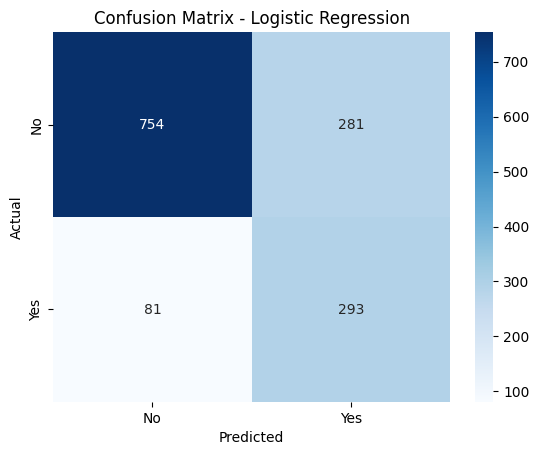

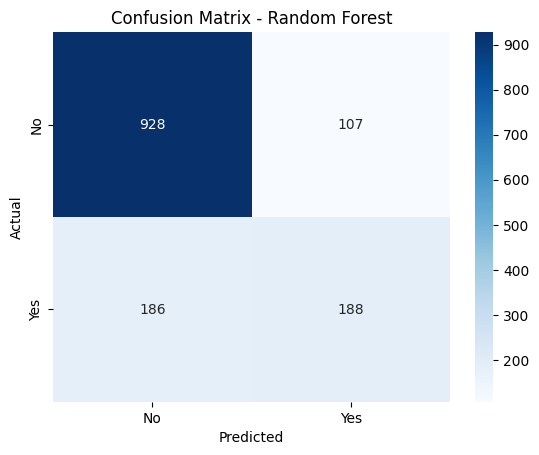

In [18]:
import matplotlib.pyplot as plt

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=["No", "Yes"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No","Yes"], yticklabels=["No","Yes"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

plot_cm(y_test, pred_lr, "Confusion Matrix - Logistic Regression")
plot_cm(y_test, pred_rf, "Confusion Matrix - Random Forest")


## ROC krivulje

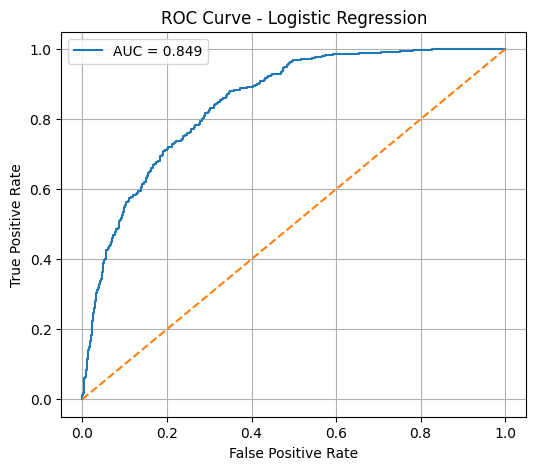

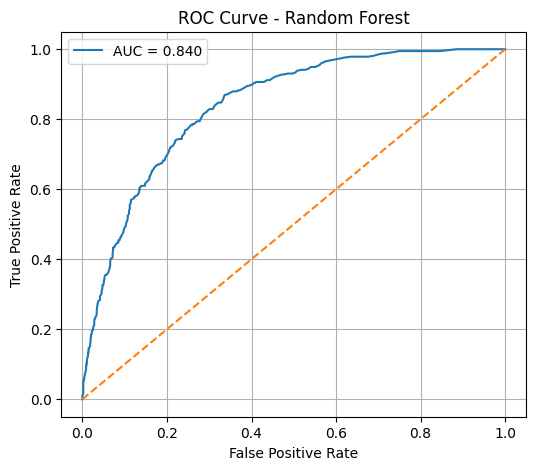

In [19]:
from sklearn.metrics import roc_curve, auc

def plot_roc(y_true, y_score, title):
    y_true_bin = (y_true == "Yes").astype(int)
    fpr, tpr, _ = roc_curve(y_true_bin, y_score)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_roc(y_test, score_lr, "ROC Curve - Logistic Regression")
plot_roc(y_test, score_rf, "ROC Curve - Random Forest")


ROC krivulje prikazuju odnos između osjetljivosti (TPR) i lažno pozitivne stope (FPR) za različite pragove klasifikacije.
Narančasta isprekidana linija predstavlja nasumični klasifikator (AUC = 0.5).

Dobiveni rezultati pokazuju da oba modela značajno nadmašuju nasumičnu predikciju.
Logistic Regression postiže AUC = 0.849, dok Random Forest postiže AUC = 0.840, što ukazuje da oba modela imaju dobru sposobnost razdvajanja churn i non-churn korisnika. Iako Random Forest može biti snažniji u složenim odnosima, u ovom eksperimentu Logistic Regression postiže blago bolji ROC-AUC.

